In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from lib import spoti
import json
import os
from typing import List, Dict, Tuple

In [2]:
DATA_PATH = os.path.join("data")

In [3]:
owen = spoti.SpotiUser("owen")
brenda = spoti.SpotiUser("brenda")
arthur = spoti.SpotiUser("arthur")
michelle = spoti.SpotiUser("michelle")

In [4]:
USERS = [owen, brenda, arthur, michelle]

In [5]:
def get_data_path(user: spoti.SpotiUser) -> str:
    return os.path.join(DATA_PATH, f"{user.username}_liked_tracks.json")

In [6]:
USERS_DF = []
for user in USERS:
    df = pd.read_json(get_data_path(user), orient="records")
    df["username"] = user.username
    USERS_DF.append(df)

df = pd.concat(USERS_DF)

In [7]:
# orient on the genres
df = df.explode("genres")

In [8]:
def simplify_genre(genre: str) -> str:
    if pd.isna(genre): return genre
    if "rock" in genre: return "rock"
    if "kpop" in genre or "k-pop" in genre: return "kpop"
    if "pop" in genre: return "pop"
    if "rap" in genre or "hip hop" in genre: return "rap"
    if "emo" in genre or "punk" in genre or "screamo" in genre or "hardcore" in genre or "dreamo" in genre or "grunge" in genre: return "emo/punk/grunge"
    if "metal" in genre: return "metal"
    if "lo-fi" in genre or "chill" in genre or "lofi" in genre: return "lo-fi"
    if "indie" in genre: return "indie"
    if "french" in genre or "francophone" in genre or "francais" in genre: return "french"
    if "house" in genre or "edm" in genre or "electro" in genre or "electronic" in genre: return "electronic"
    if "jazz" in genre: return "jazz"
    if "classical" in genre: return "classical"
    if "r&b" in genre or "soul" in genre: return "r&b"
    return genre

In [9]:
df["simplified_genres"] = df["genres"].apply(simplify_genre)

In [10]:
px.bar(df.groupby("genres").count()["id"].sort_values(ascending=False)[:30])

In [11]:
px.bar(df.groupby("simplified_genres").count()["id"].sort_values(ascending=False)[:30])

In [12]:
numeric_features = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "loudness",
    "duration_ms",
]

<Figure size 2000x1000 with 0 Axes>

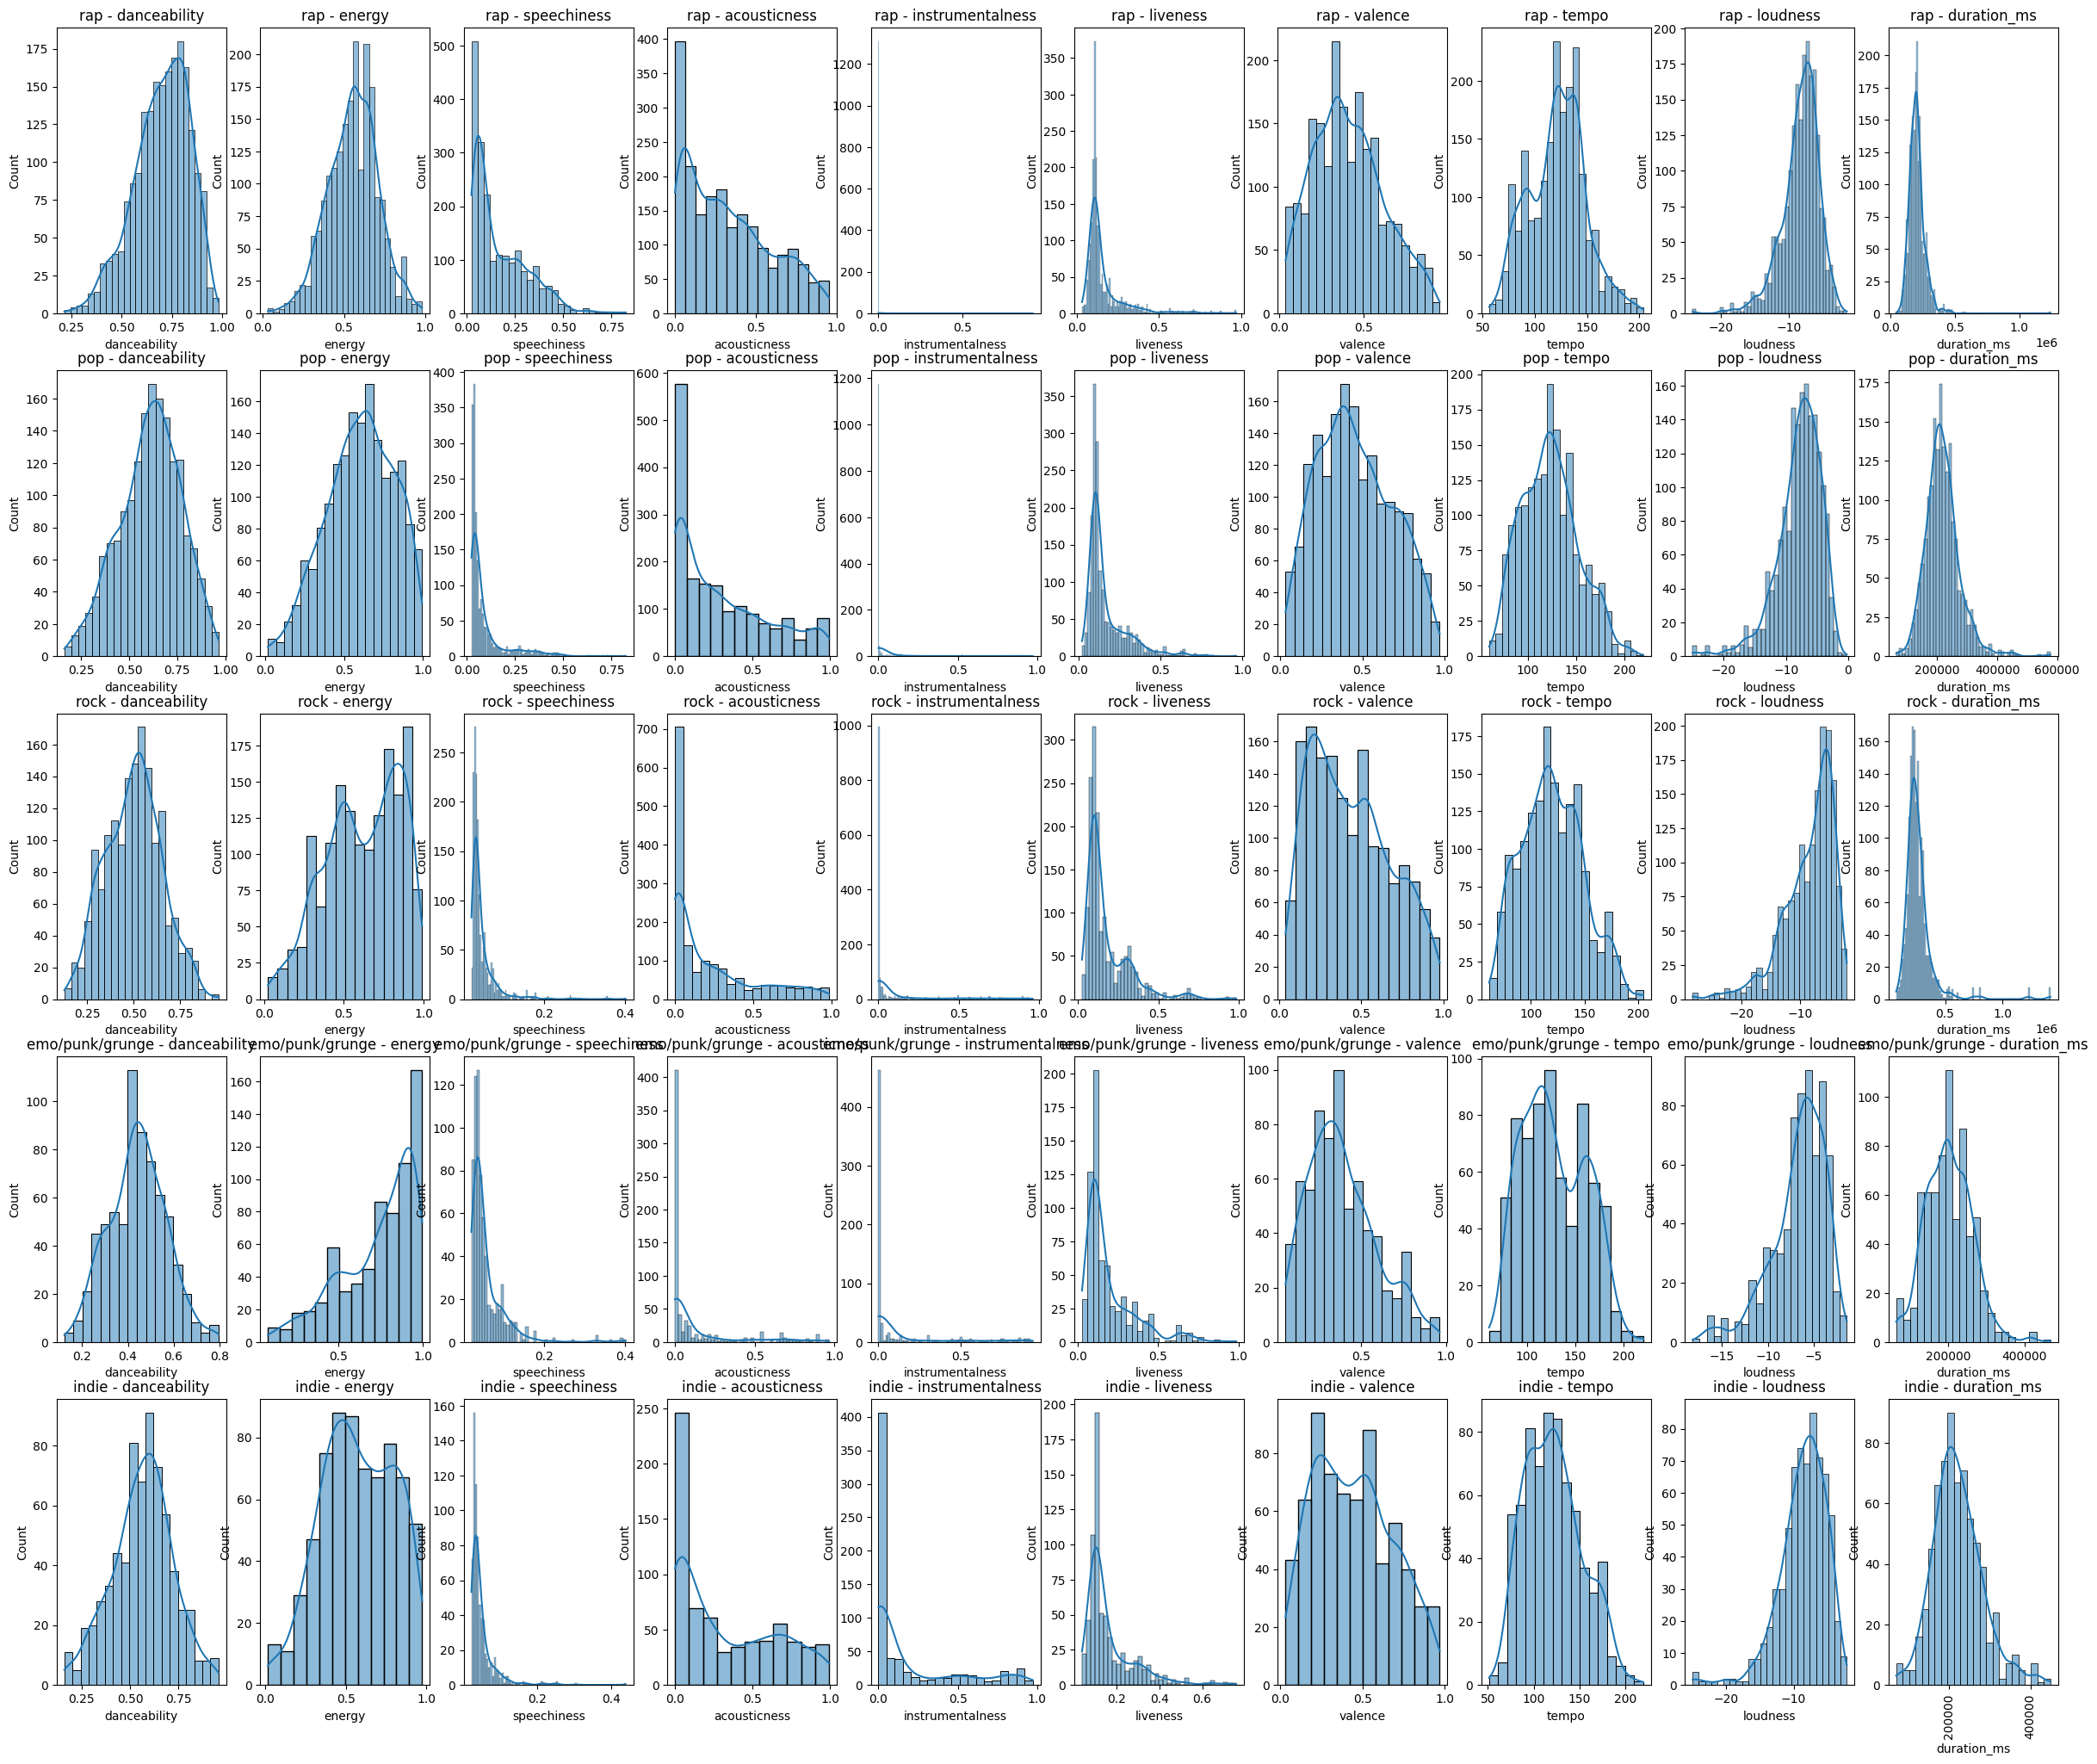

In [13]:
plt.figure(figsize=(20,10))

top_genres = df.groupby("simplified_genres").count()["id"].sort_values(ascending=False)[:5].index
fig, axs = plt.subplots(len(top_genres), len(numeric_features), figsize=(30, len(top_genres)*5))

for i, genre in enumerate(top_genres):
    for j, feature in enumerate(numeric_features):
        sns.histplot(df[df["simplified_genres"] == genre][feature], ax=axs[i][j], kde=True)
        axs[i][j].set_title(f"{genre} - {feature}")

plt.xticks(rotation=90)
plt.show()

rap


<Figure size 2000x1000 with 0 Axes>

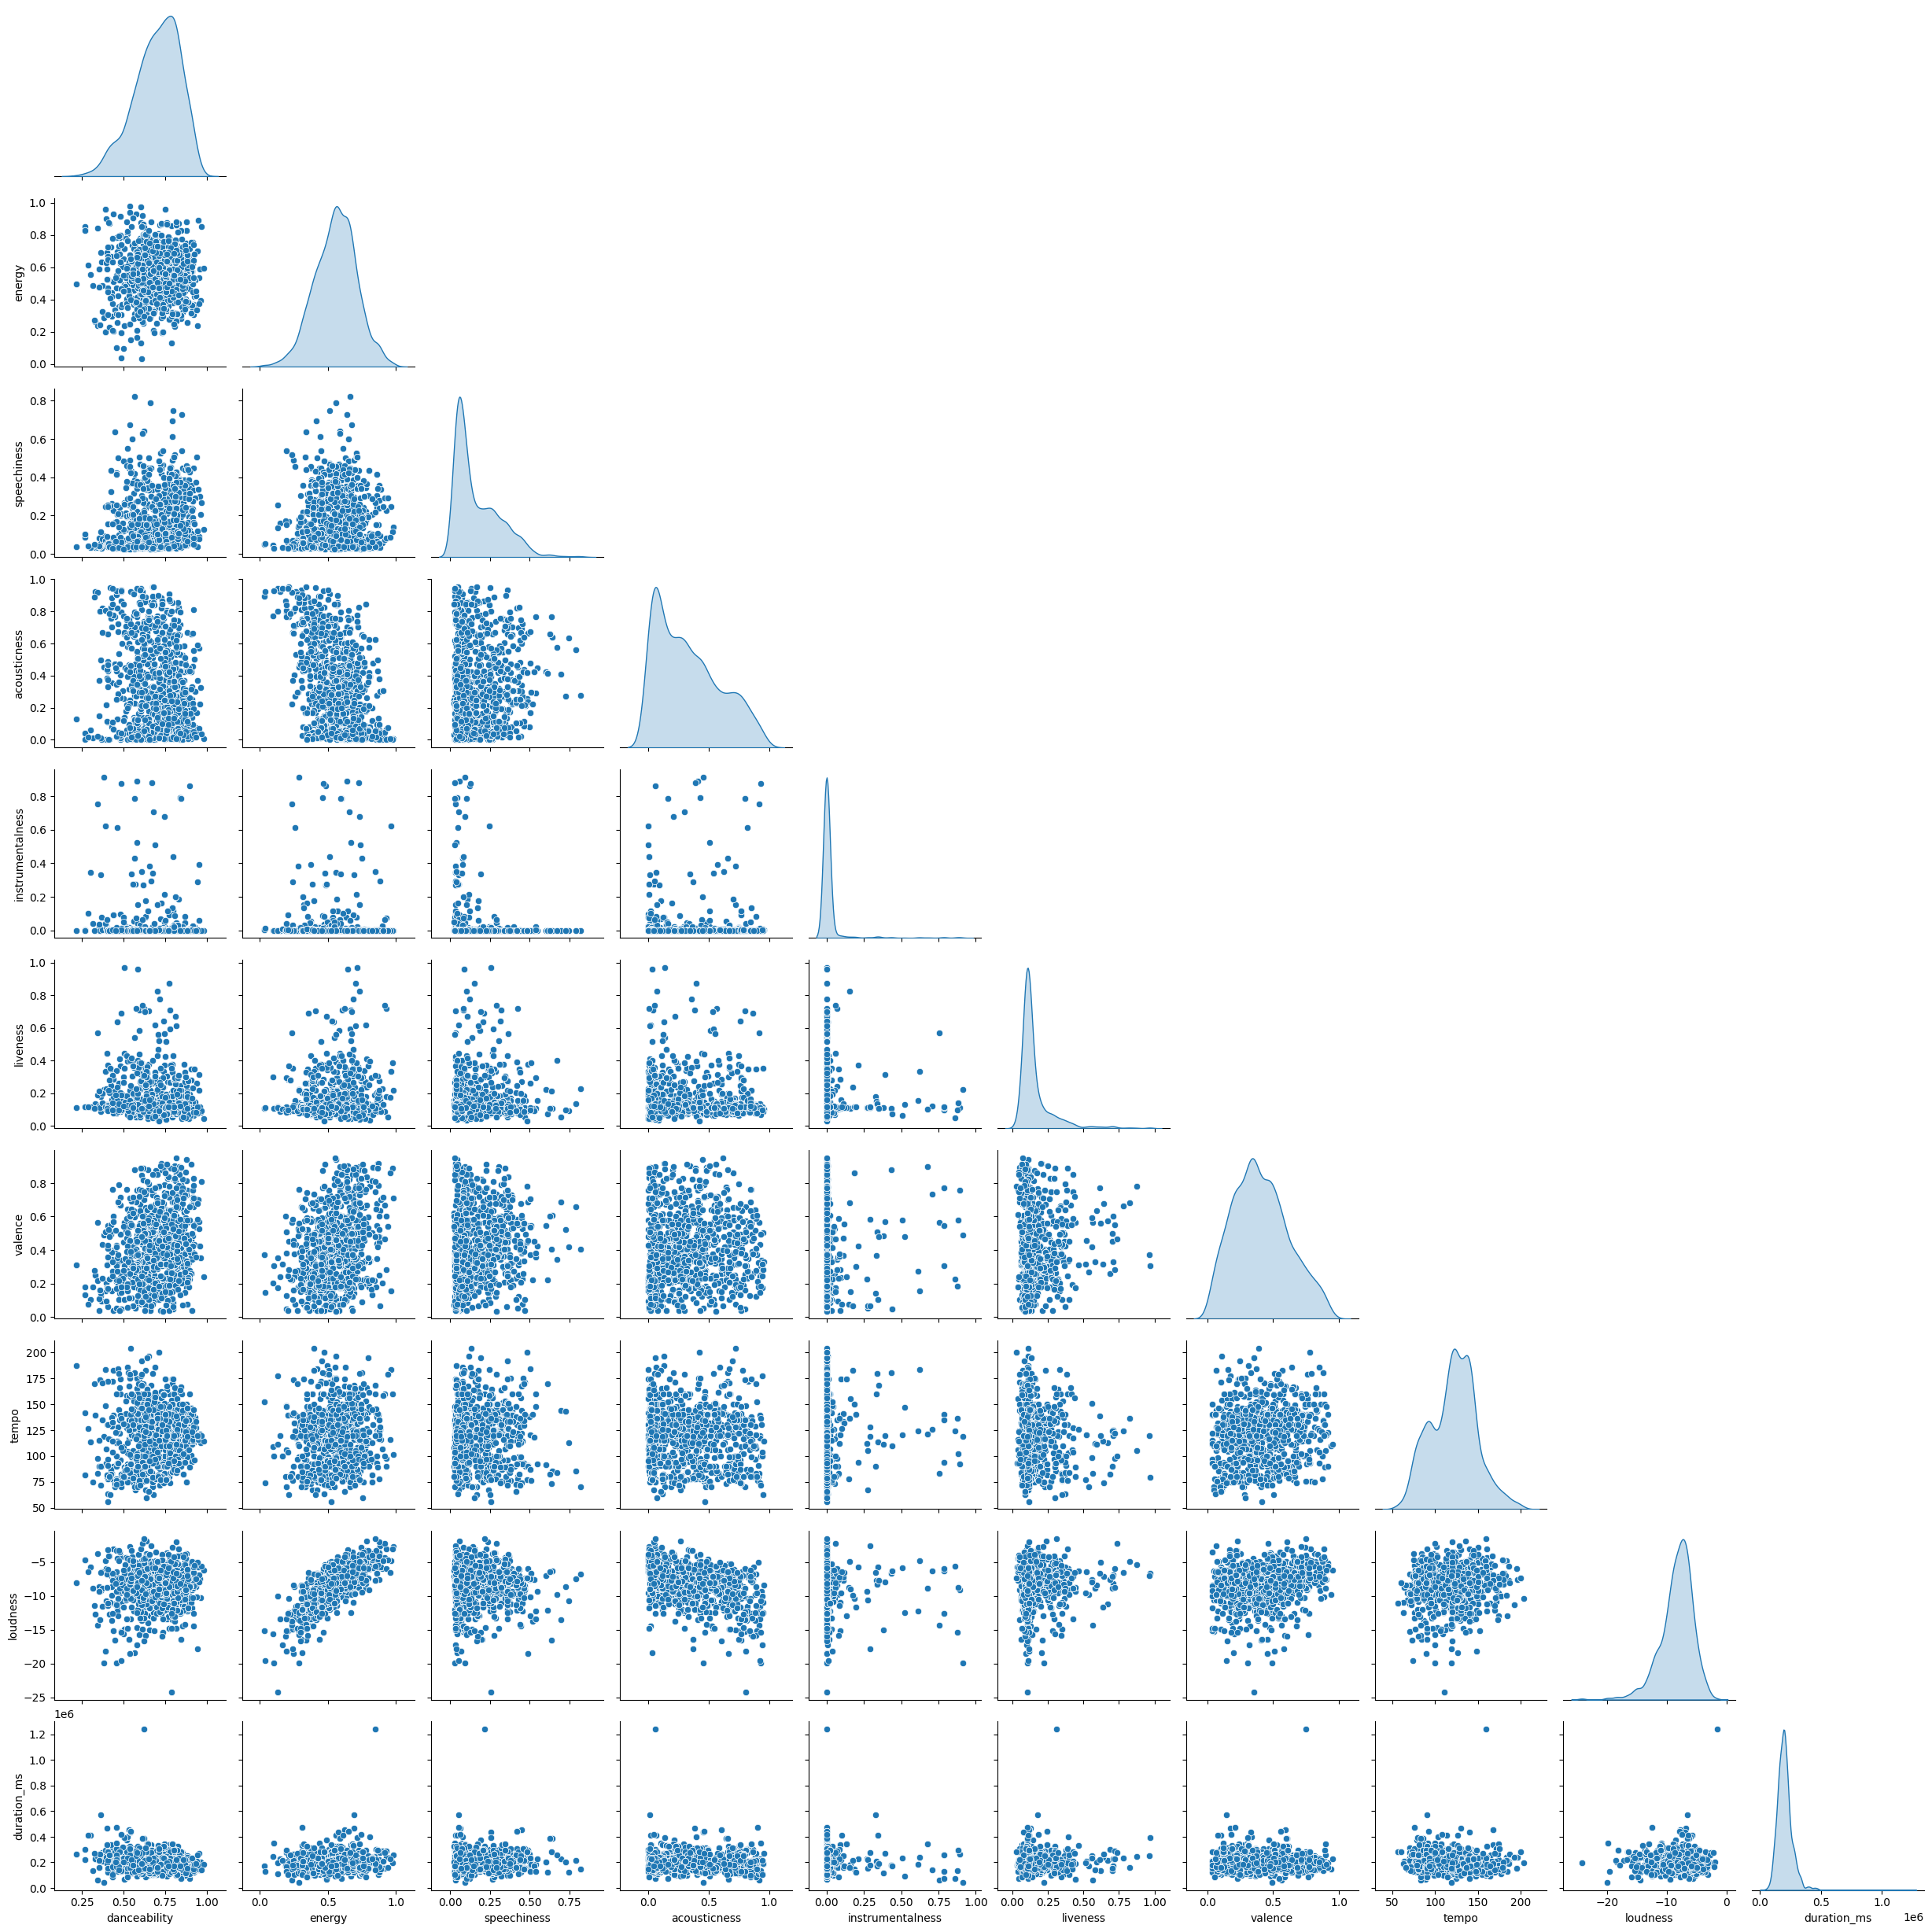

pop


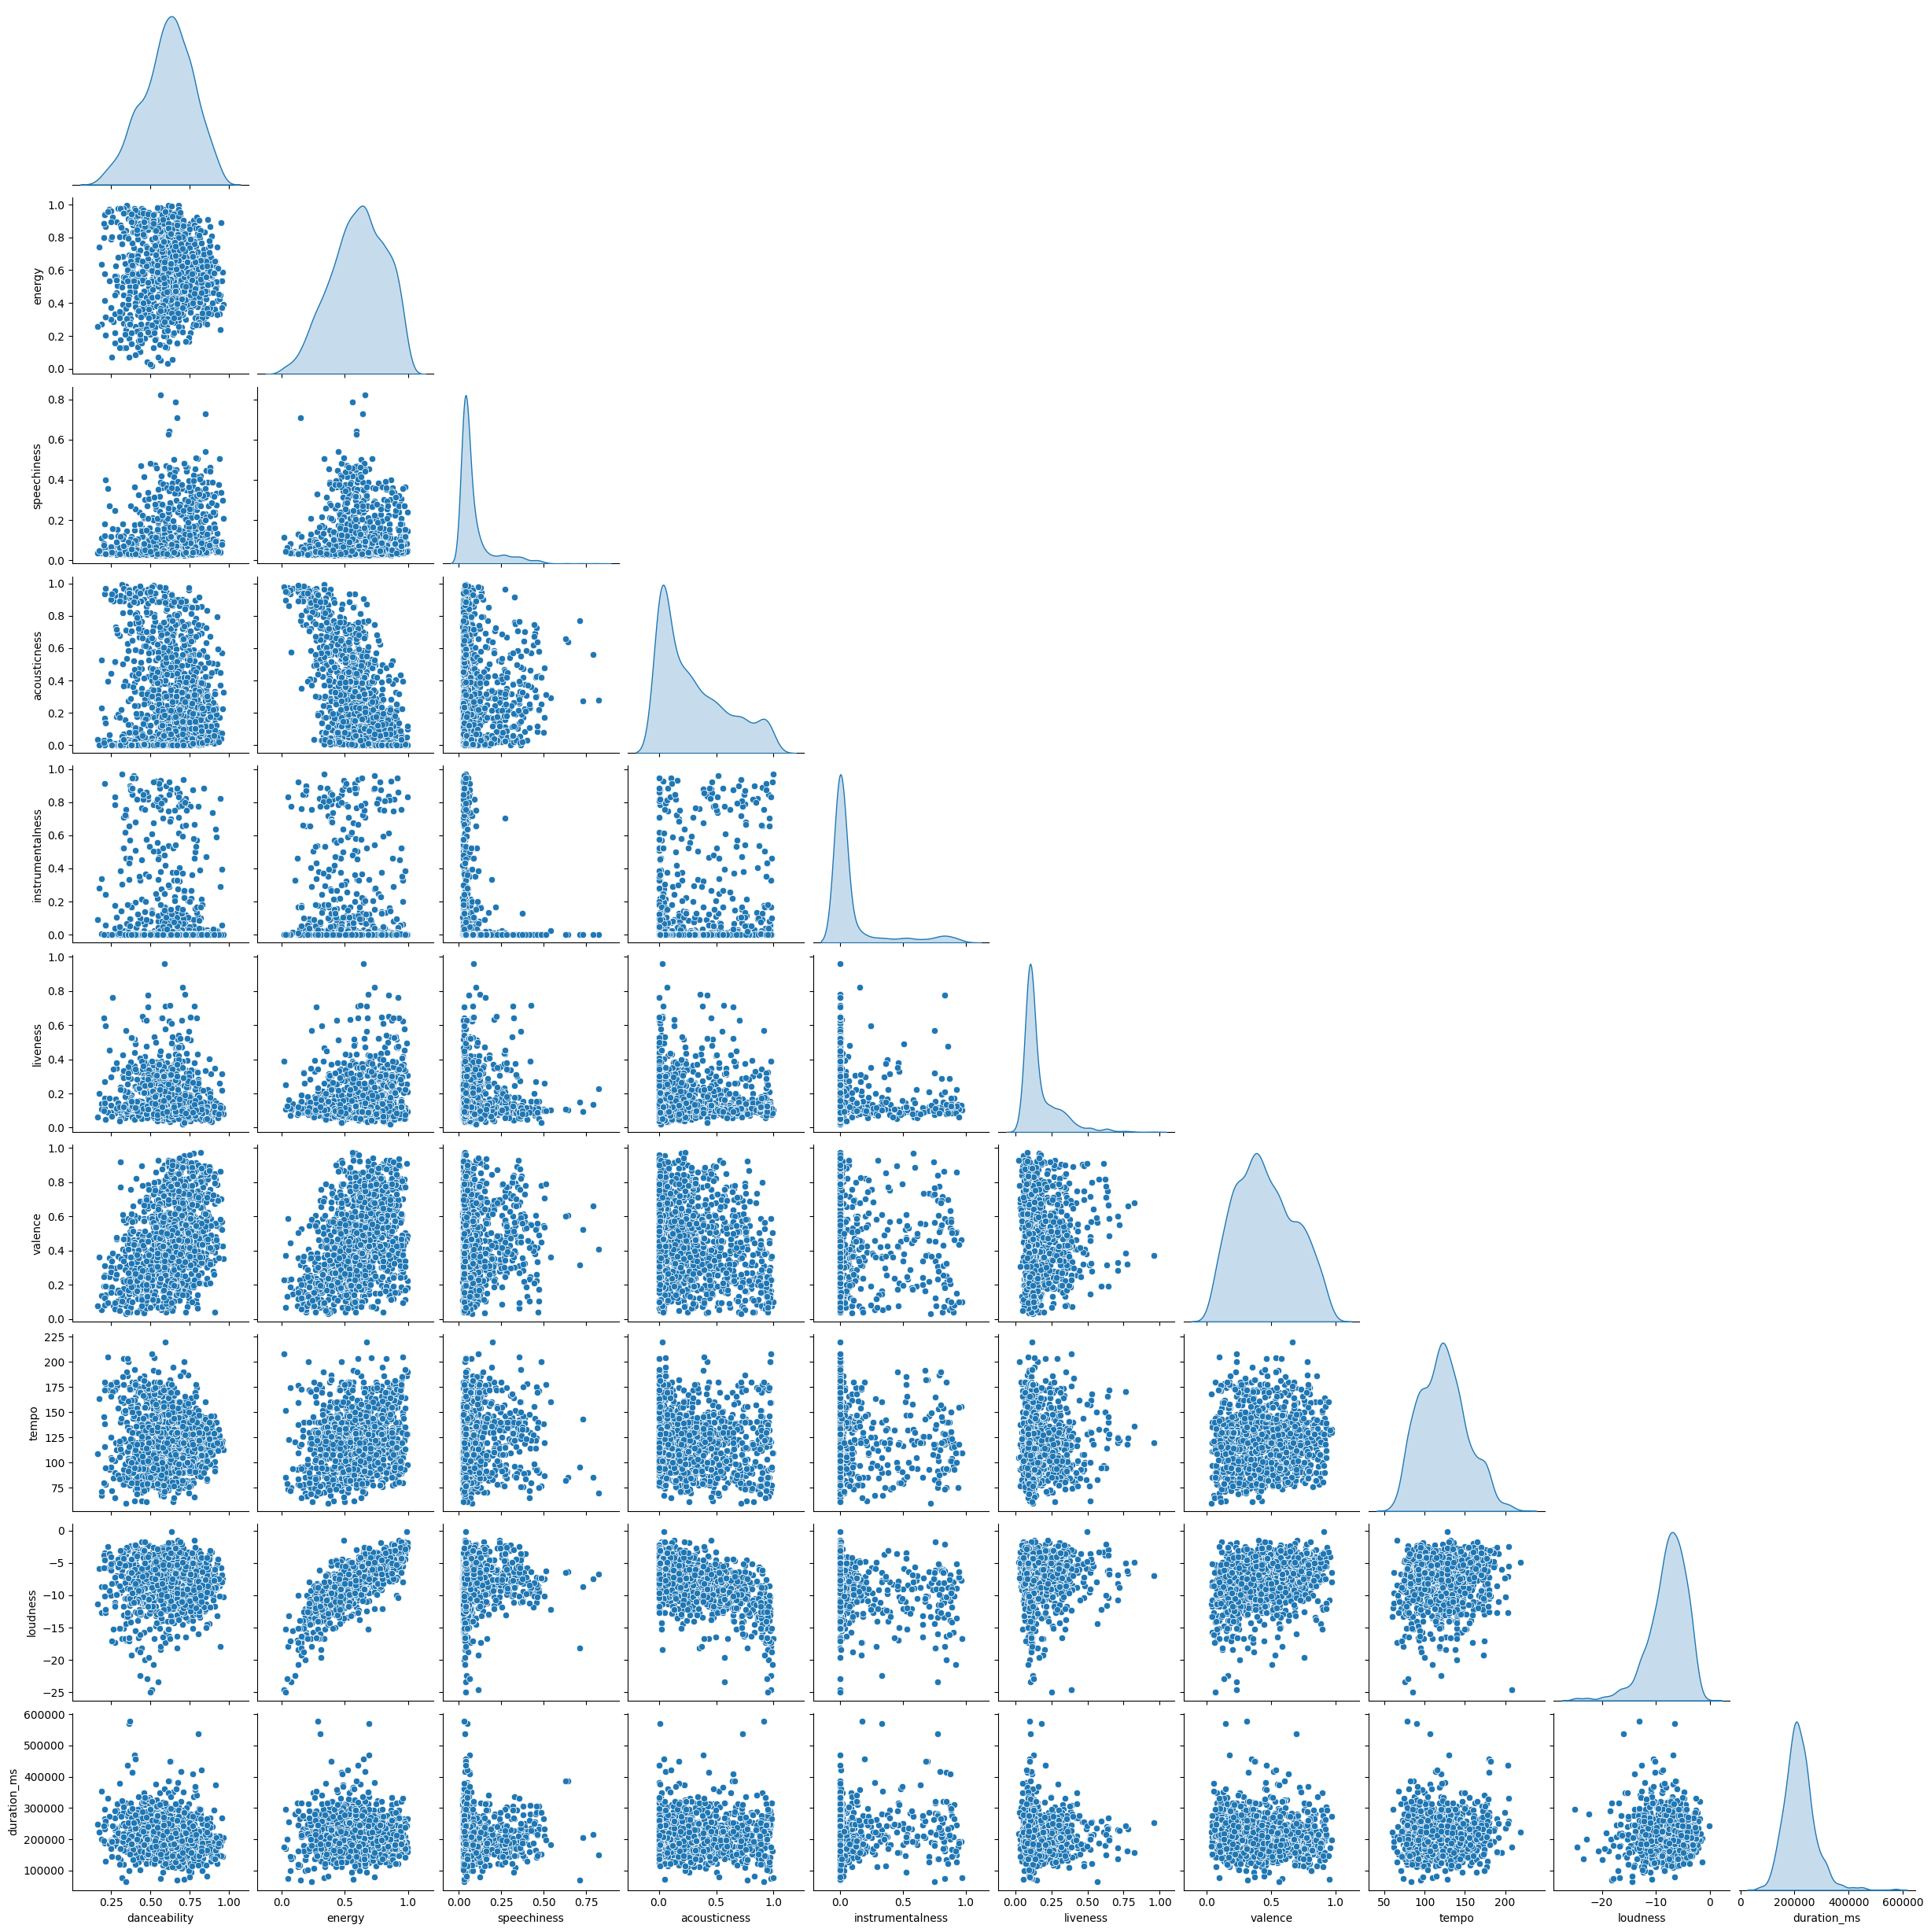

rock


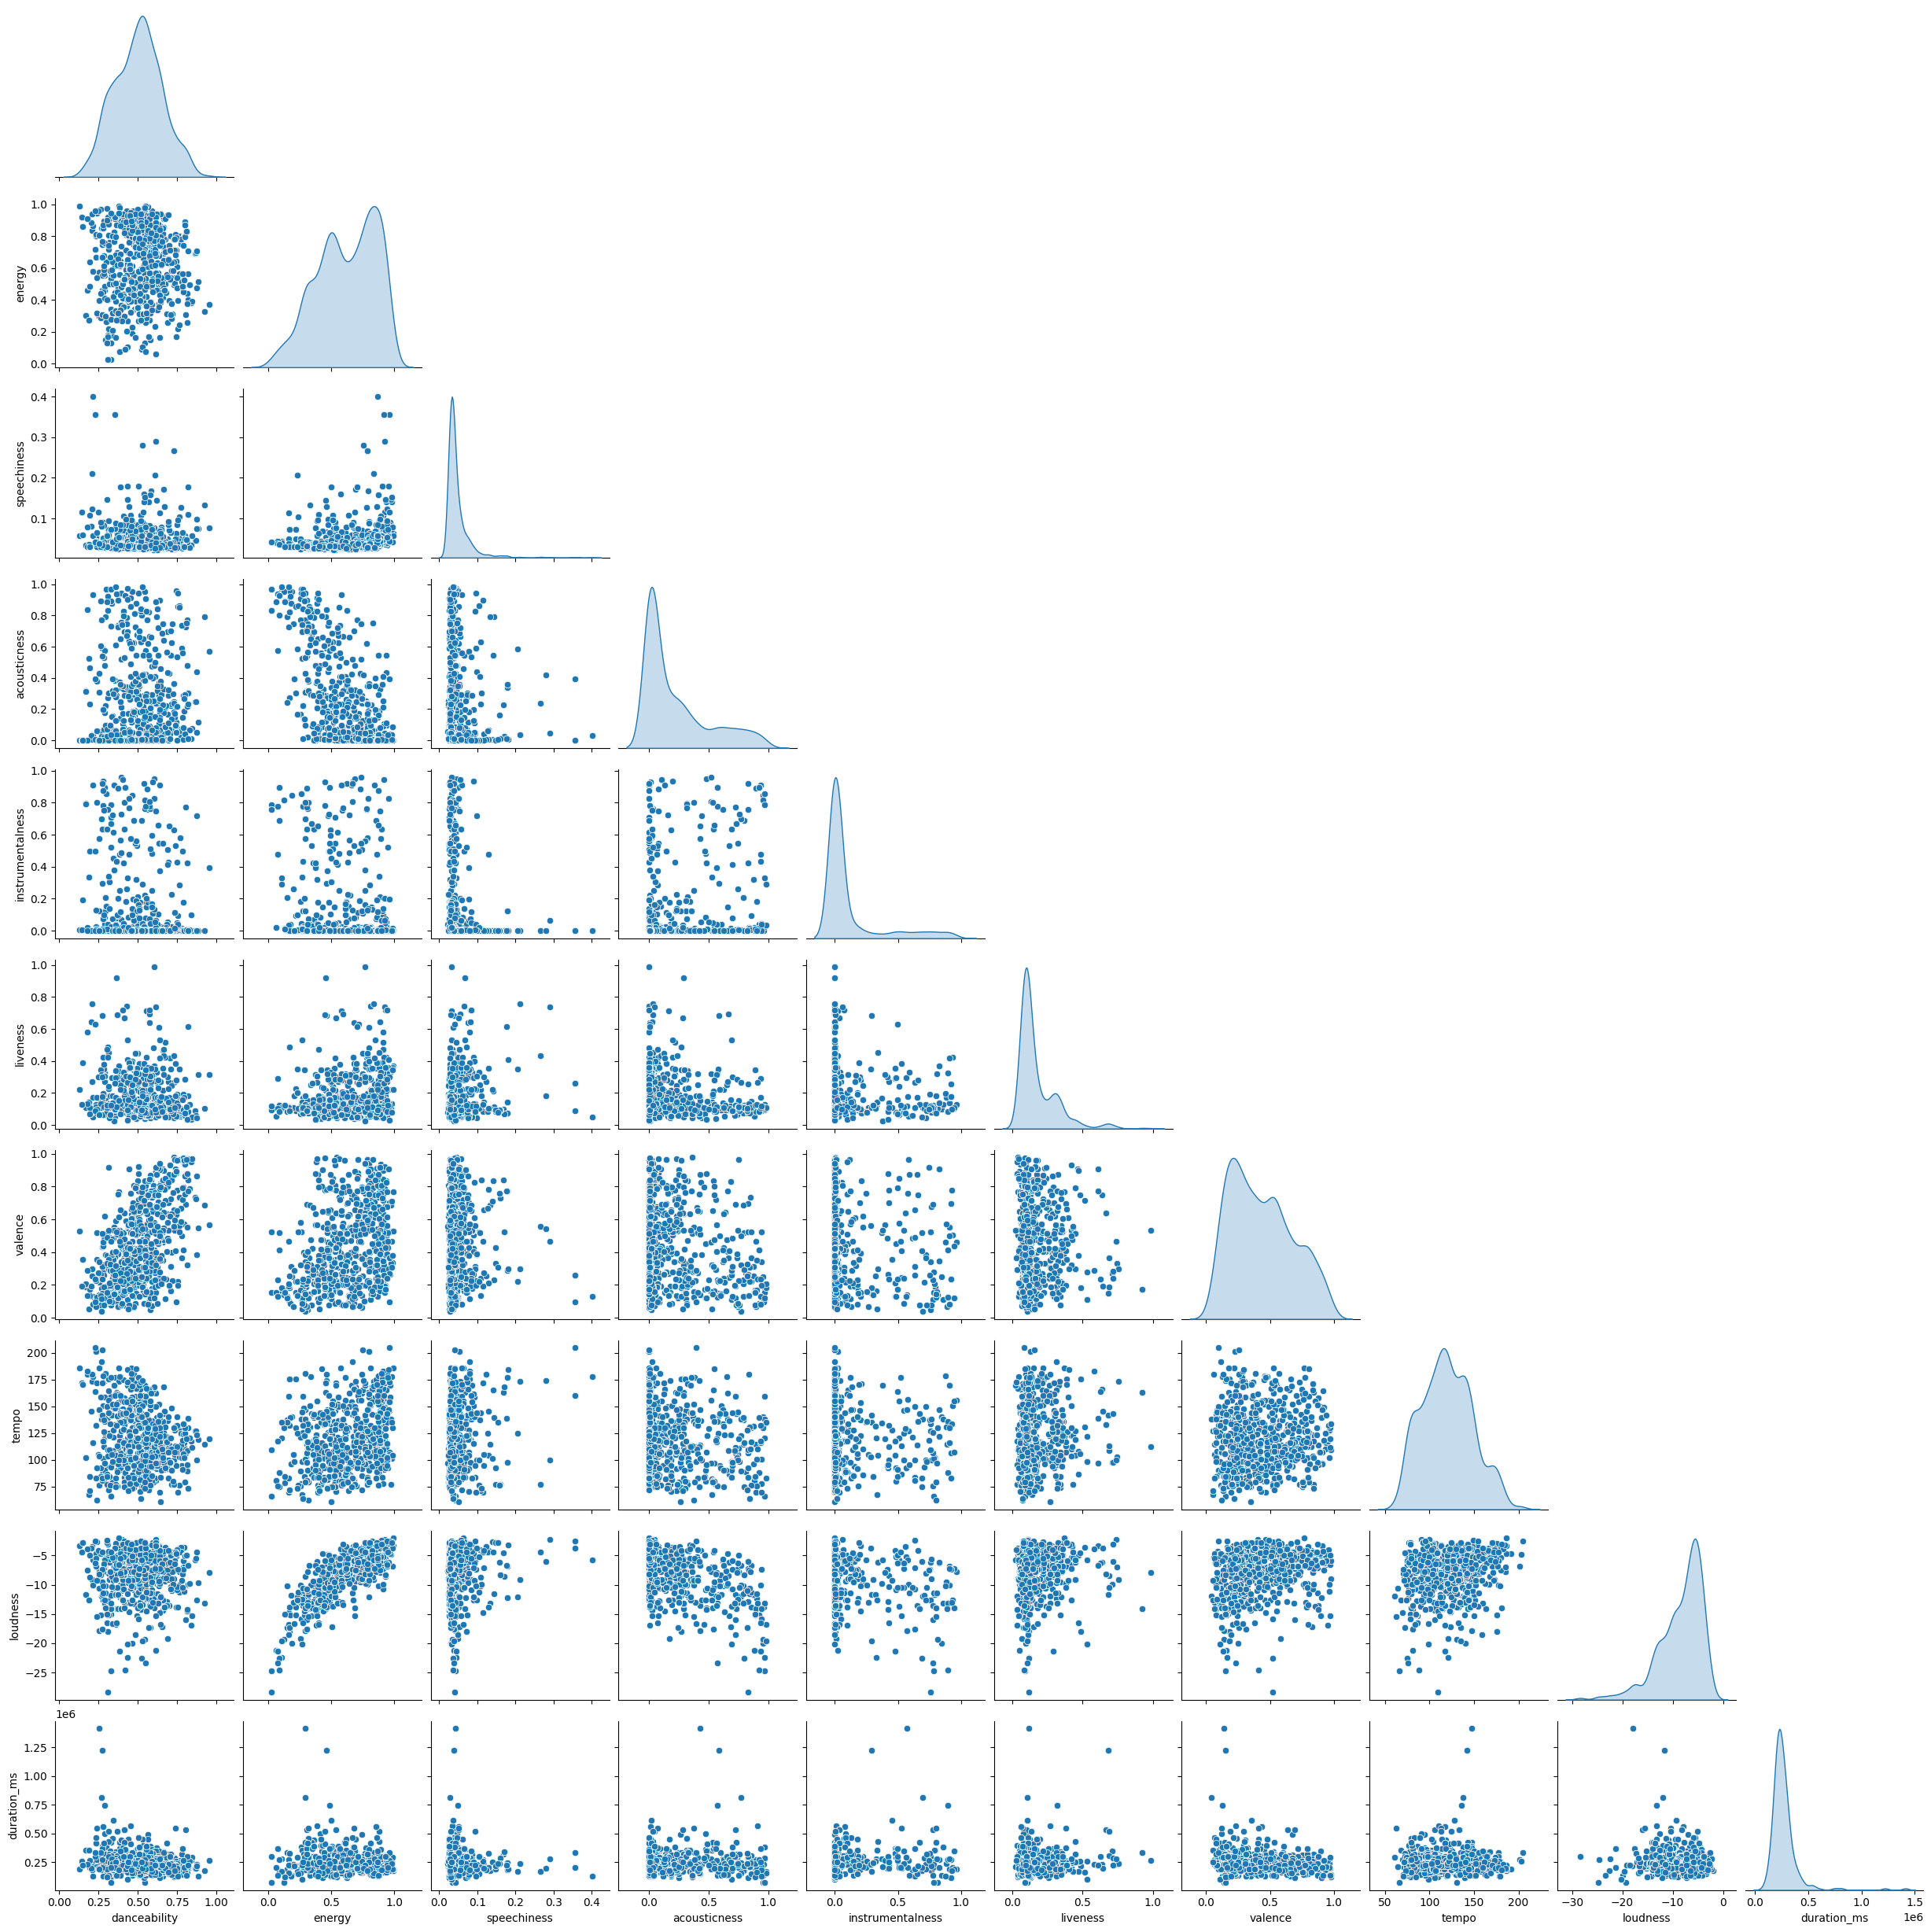

emo/punk/grunge


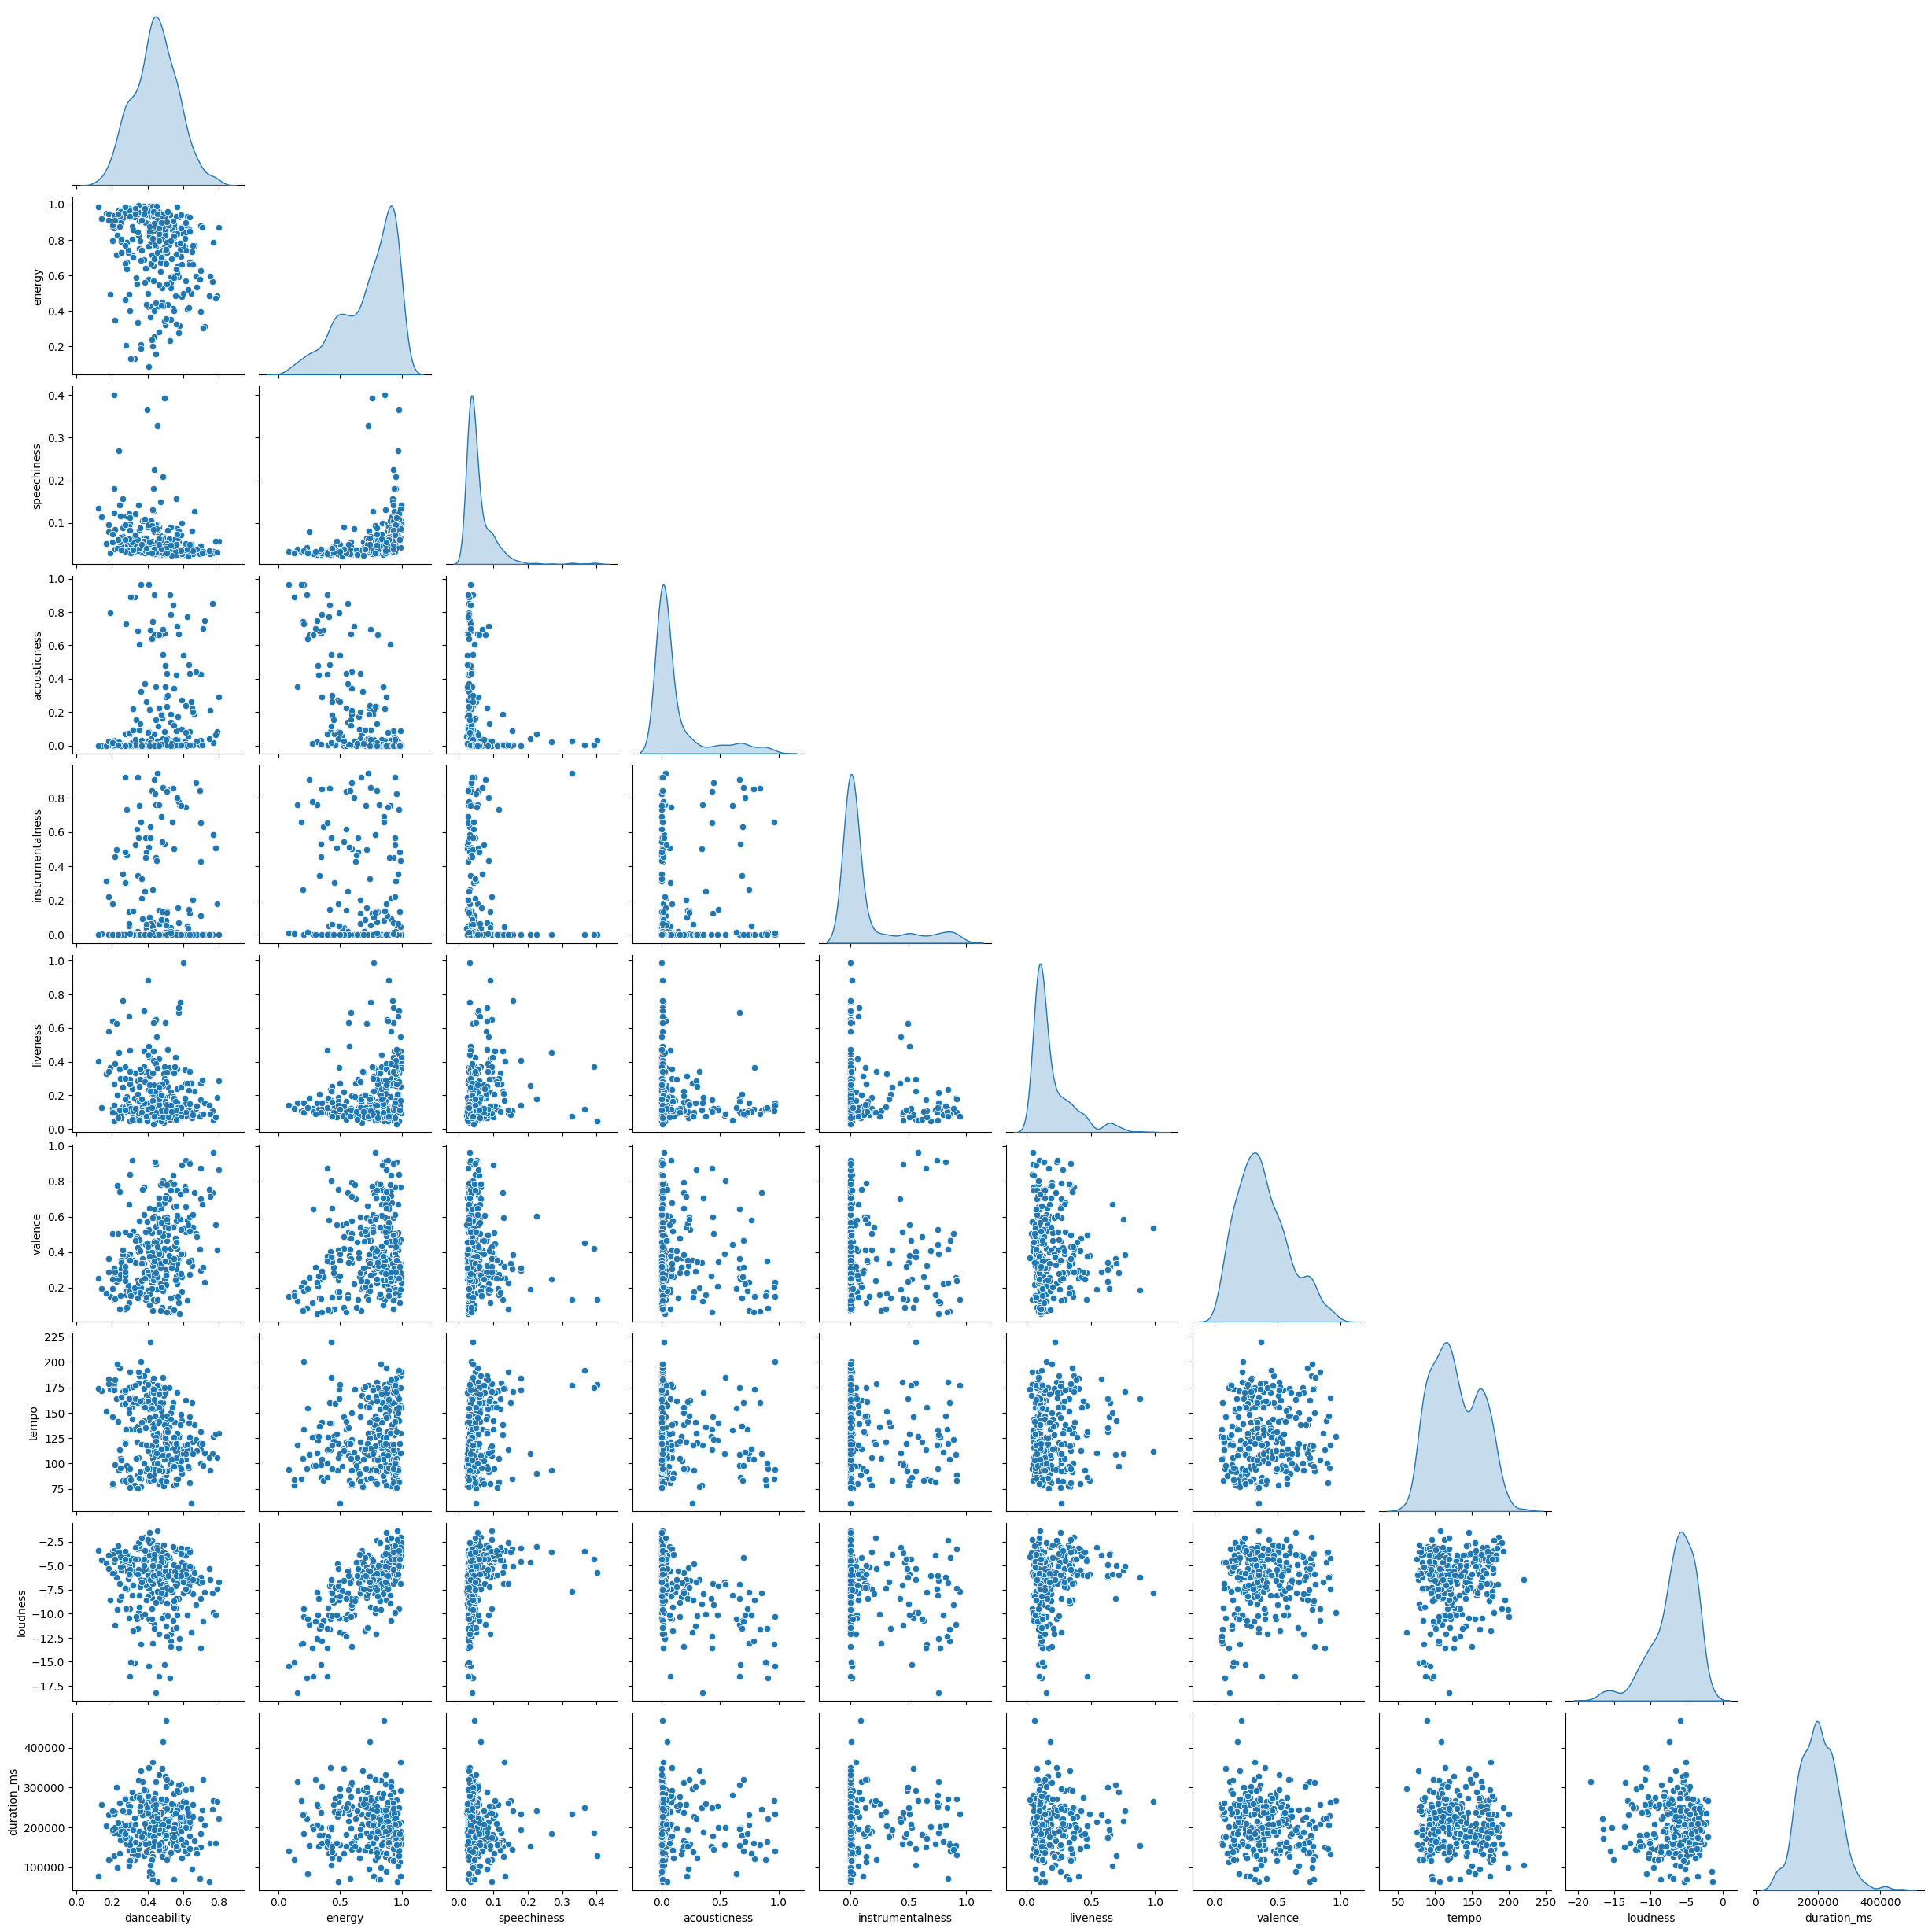

indie


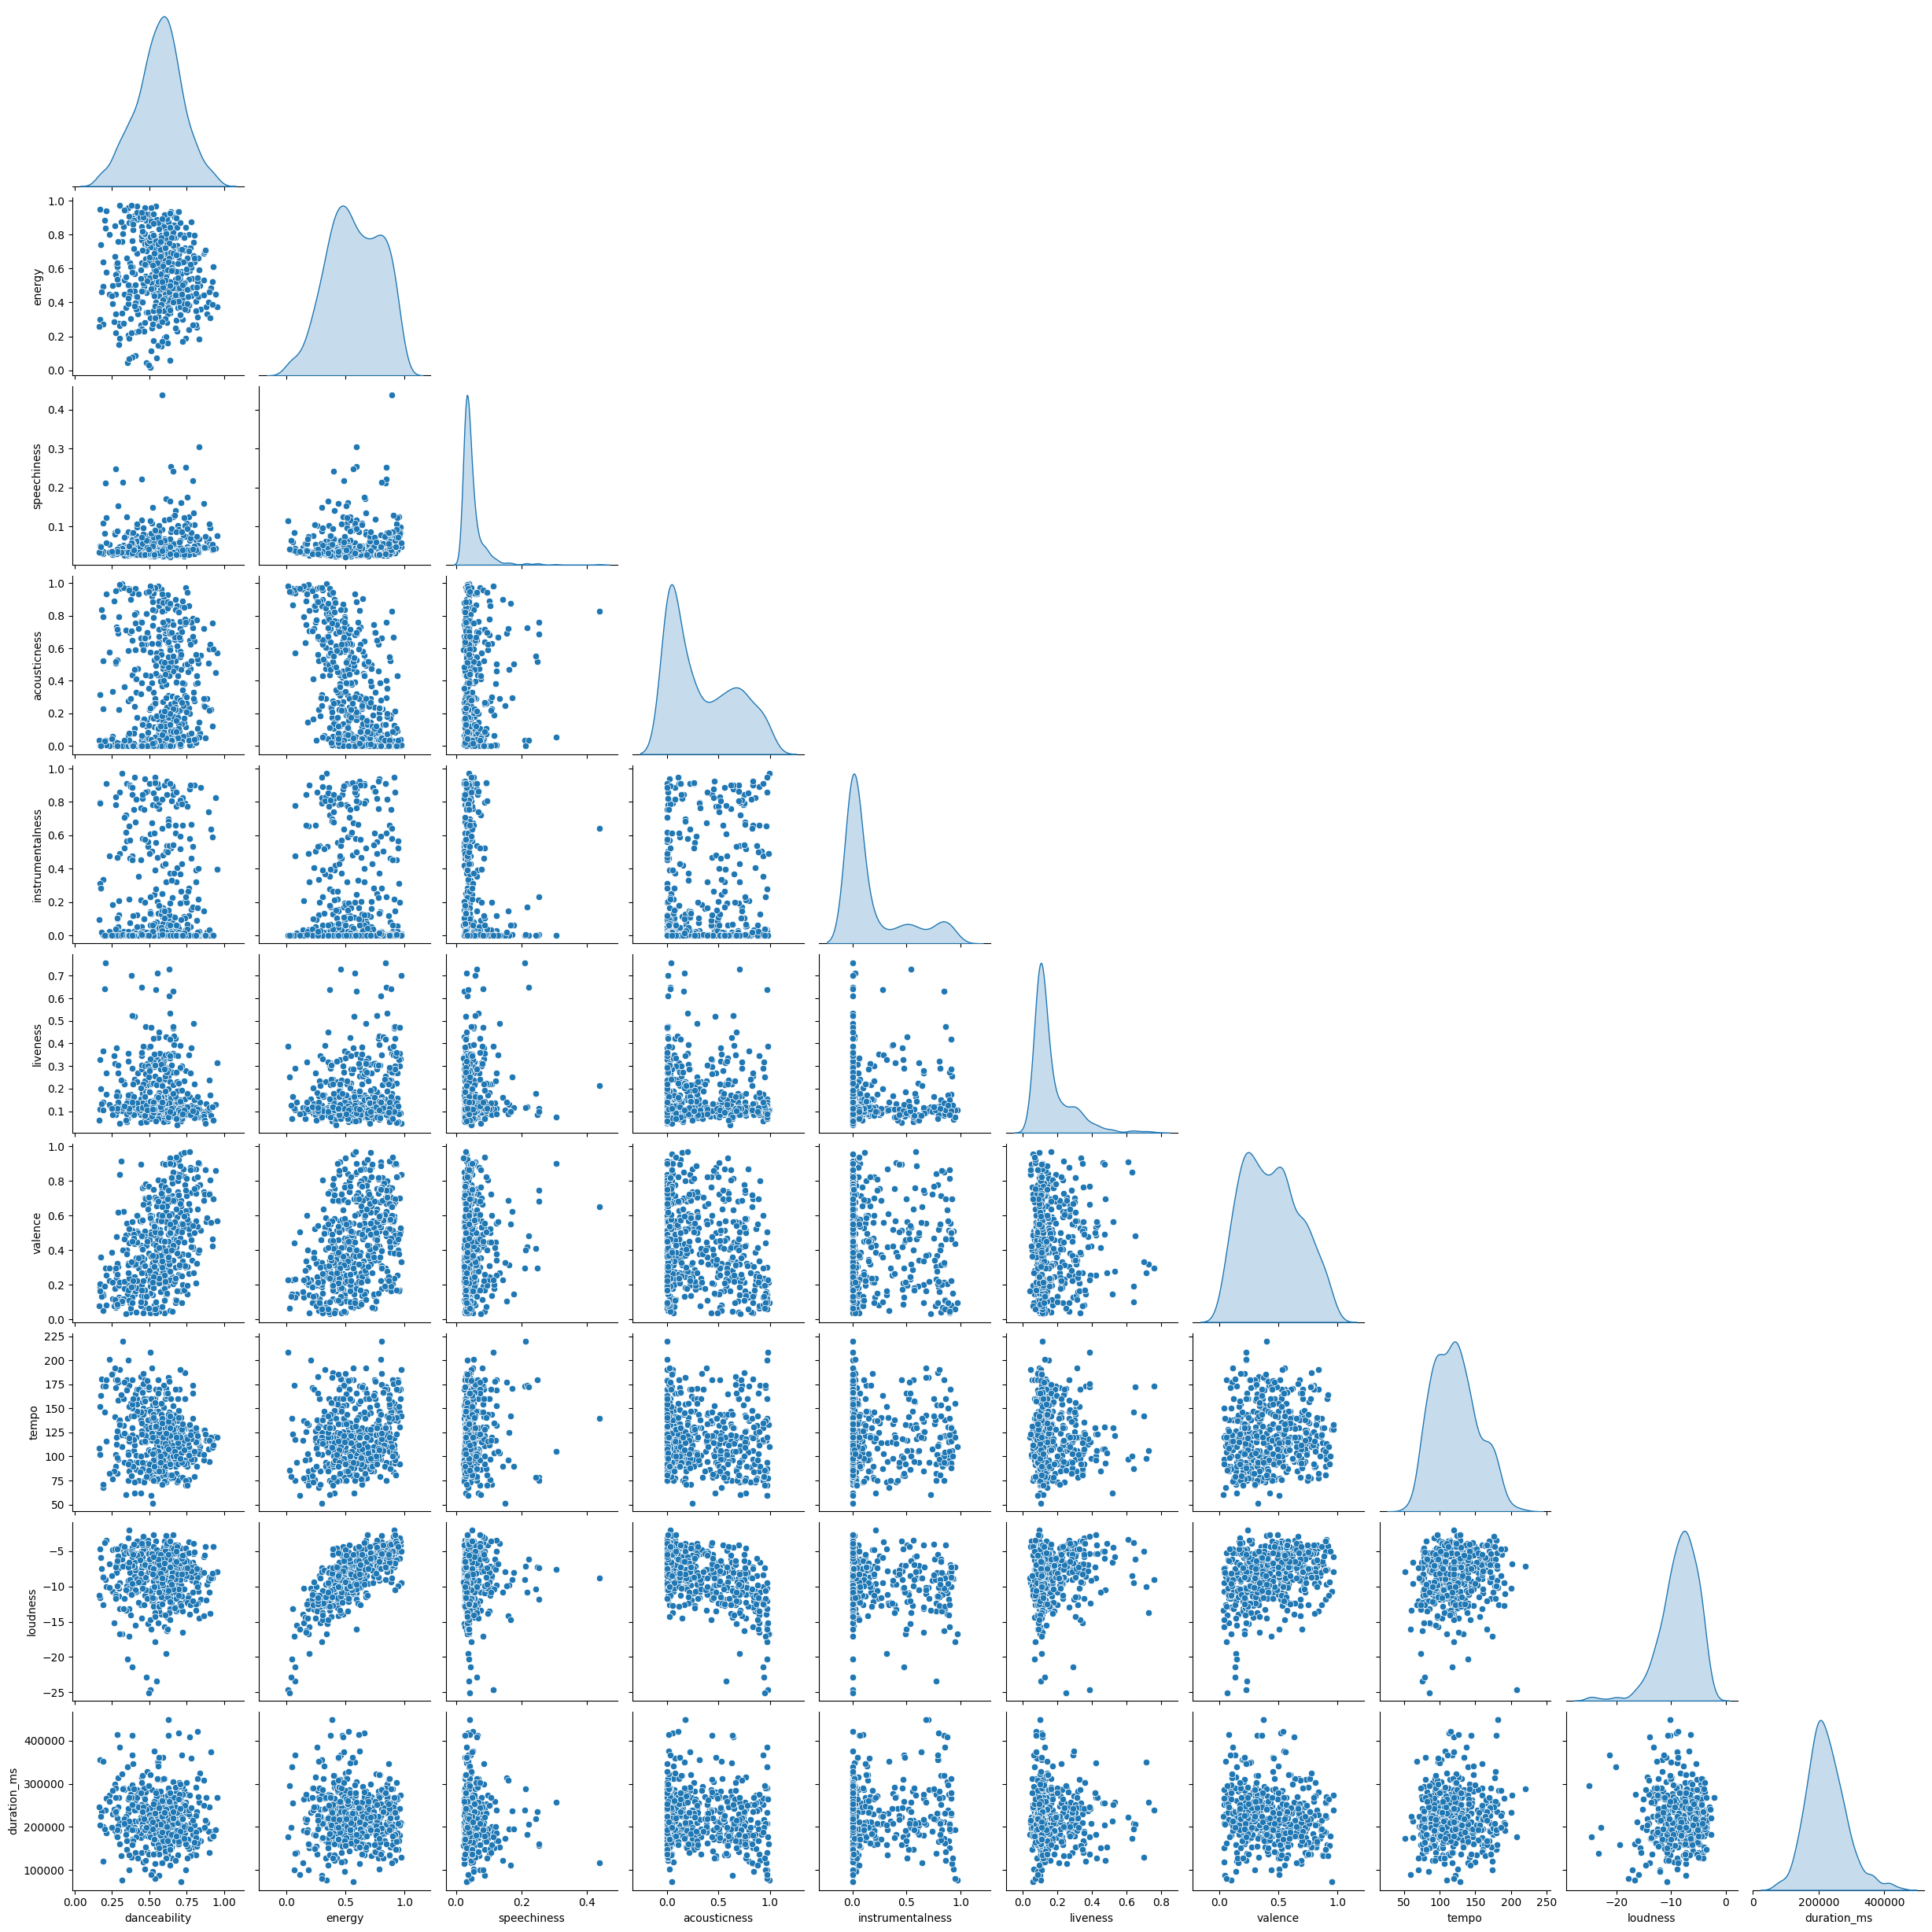

In [14]:
plt.figure(figsize=(20,10))

for i, genre in enumerate(top_genres):
    print(genre)
    sns.pairplot(df[df["simplified_genres"] == genre][numeric_features], diag_kind="kde", corner=True)
    plt.show()

In [15]:
# take the minimum of samples of all top genres
min_samples = min([df[df["simplified_genres"] == genre].shape[0] for genre in top_genres])
min_samples

684

In [16]:
# take random <min_samples> samples from each genre
df_sample = pd.concat([df[df["simplified_genres"] == genre].sample(min_samples) for genre in top_genres])
df_sample

,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,valence,tempo,type_features,uri_features,track_href,analysis_url,duration_ms_features,time_signature,username,simplified_genres
837,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,157506,True,{'isrc': 'USRC11901793'},{'spotify': 'https://open.spotify.com/track/6A...,https://api.spotify.com/v1/tracks/6AomCkEOQUOD...,6AomCkEOQUODCYzQwH4SWC,...,0.681,135.993,audio_features,spotify:track:6AomCkEOQUODCYzQwH4SWC,https://api.spotify.com/v1/tracks/6AomCkEOQUOD...,https://api.spotify.com/v1/audio-analysis/6Aom...,157507,4,michelle,rap
632,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,222093,True,{'isrc': 'FR9EI2100140'},{'spotify': 'https://open.spotify.com/track/4o...,https://api.spotify.com/v1/tracks/4od5tjUz1iLf...,4od5tjUz1iLfQj4y4uiK0w,...,0.483,123.985,audio_features,spotify:track:4od5tjUz1iLfQj4y4uiK0w,https://api.spotify.com/v1/tracks/4od5tjUz1iLf...,https://api.spotify.com/v1/audio-analysis/4od5...,222093,4,owen,rap
599,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,106333,True,{'isrc': 'USCM51600090'},{'spotify': 'https://open.spotify.com/track/3p...,https://api.spotify.com/v1/tracks/3ppVO2tyWRRz...,3ppVO2tyWRRznNmONvt7Se,...,0.242,132.031,audio_features,spotify:track:3ppVO2tyWRRznNmONvt7Se,https://api.spotify.com/v1/tracks/3ppVO2tyWRRz...,https://api.spotify.com/v1/audio-analysis/3ppV...,106333,3,owen,rap
1344,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,260053,False,{'isrc': 'BEEN91820002'},{'spotify': 'https://open.spotify.com/track/3b...,https://api.spotify.com/v1/tracks/3bun74bry87E...,3bun74bry87EnvCRktihNG,...,0.344,120.021,audio_features,spotify:track:3bun74bry87EnvCRktihNG,https://api.spotify.com/v1/tracks/3bun74bry87E...,https://api.spotify.com/v1/audio-analysis/3bun...,260053,4,owen,rap
957,"{'album_type': 'single', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,206419,False,{'isrc': 'TCADY1815622'},{'spotify': 'https://open.spotify.com/track/6Q...,https://api.spotify.com/v1/tracks/6Q0KwNIXup7W...,6Q0KwNIXup7WUNlpmOjkFU,...,0.551,82.524,audio_features,spotify:track:6Q0KwNIXup7WUNlpmOjkFU,https://api.spotify.com/v1/tracks/6Q0KwNIXup7W...,https://api.spotify.com/v1/audio-analysis/6Q0K...,206420,4,owen,rap
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1695,"{'album_type': 'single', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,294306,False,{'isrc': 'FR9Z61700005'},{'spotify': 'https://open.spotify.com/track/5c...,https://api.spotify.com/v1/tracks/5c5DbC1kewHB...,5c5DbC1kewHBZgwnWyL5XD,...,0.305,126.019,audio_features,spotify:track:5c5DbC1kewHBZgwnWyL5XD,https://api.spotify.com/v1/tracks/5c5DbC1kewHB...,https://api.spotify.com/v1/audio-analysis/5c5D...,294307,4,owen,indie
653,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,233655,False,{'isrc': 'GBUM71105426'},{'spotify': 'https://open.spotify.com/track/5Q...,https://api.spotify.com/v1/tracks/5Q1H7ASDiJpA...,5Q1H7ASDiJpACNx5ziyhuN,...,0.453,102.473,audio_features,spotify:track:5Q1H7ASDiJpACNx5ziyhuN,https://api.spotify.com/v1/tracks/5Q1H7ASDiJpA...,https://api.spotify.com/v1/audio-analysis/5Q1H...,233655,4,michelle,indie
800,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,

In [17]:
# compute the mean of each feature for each genre
df_mean = df_sample.groupby("simplified_genres")[numeric_features].mean()
df_mean

,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms
simplified_genres,,,,,,,,,,
emo/punk/grunge,0.442368,0.735995,0.058804,0.119758,0.123737,0.193751,0.384613,128.000086,-6.625158,201189.457602
indie,0.564266,0.575635,0.049309,0.332103,0.182575,0.164592,0.442448,121.645161,-8.544814,222701.422515
pop,0.613216,0.611194,0.085048,0.293422,0.091597,0.167283,0.461793,121.694230,-7.737284,218819.903509
rap,0.699143,0.562351,0.172873,0.338425,0.018897,0.166123,0.411193,120.170130,-8.217680,205043.809942
rock,0.497475,0.622459,0.049015,0.216598,0.112841,0.175499,0.443064,119.522889,-8.323333,273616.986842


In [20]:
fig = px.scatter_matrix(
    df_sample,
    dimensions=numeric_features,
    color="simplified_genres",
    height=2200,
    width=1700,
)

fig.update_traces(showupperhalf=False)
fig.update_layout(title="Spotify Song Features")
fig.update_traces(marker=dict(opacity=0.1, line=dict(width=0.5, color="white")))

fig.show()